<a href="https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_2_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_2_Linear_Algebra.ipynb)

# MAT 422 - Section 1.2: Linear Algebra Concepts in Python

**Topics:** linear spaces, orthogonality, Gram-Schmidt process, eigenvalues and eigenvectors

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.2.1 Linear Spaces

A linear space is closed under vector addition and scalar multiplication. In this example, vectors in R3 stay in R3 after we add them or multiply them by scalars. We also show a span calculation: a linear combination of two vectors is still in the same space.

In [16]:
u = np.array([2, -1, 3], dtype=float)
v = np.array([-4, 5, 1], dtype=float)
c = 2.5

print("u =", u)
print("v =", v)
print("u + v =", u + v)
print("c * u =", c * u)
print("linear combination 3u - 2v =", 3*u - 2*v)
print("zero vector =", np.zeros_like(u))
print("additive inverse check u + (-u) =", u + (-u))

u = [ 2. -1.  3.]
v = [-4.  5.  1.]
u + v = [-2.  4.  4.]
c * u = [ 5.  -2.5  7.5]
linear combination 3u - 2v = [ 14. -13.   7.]
zero vector = [0. 0. 0.]
additive inverse check u + (-u) = [0. 0. 0.]


A useful non-example is the set of vectors in R2 whose first coordinate is exactly 1. It is not a vector space because multiplying by most scalars leaves the set.

In [17]:
w = np.array([1, 3], dtype=float)
scaled_w = 2 * w
print("w =", w)
print("2w =", scaled_w)
print("Is 2w still in the set first coordinate = 1?", np.isclose(scaled_w[0], 1))

w = [1. 3.]
2w = [2. 6.]
Is 2w still in the set first coordinate = 1? False


(Expanded) Vector spaces also must satisfy 8 axioms:
For vectors u, v, w, and scalars c, d:

Associativity: u + (v + w) = (u + v) + w

Commutativity: u + v = v + u

Identity: There is an "zero vector" such that for all vectors v, v + 0 = v.

Inverse: For every vector v, there exists another vector -v, such that v + (-v) = 0.

Compatibility of scalar multiplication wtih field multiplication: c(dv) = (cd)v

Identity element of scalar multiplication: 1v = v, where 1 is the multiplicative identity of the scalar field.

Distributivity of scalar multiplication with respect to vector addition: c(u + v) = cu + cv

Distributivity of scalar multiplication with respect to field addition: (c + d)v = cv + dv

In [18]:
u = np.array([2, -1, 3], dtype=float)
v = np.array([-4, 5, 1], dtype=float)
w = np.array([1, 3, 0], dtype=float)
c = 2.5
d = -1
zero = np.zeros_like(u)
minusu = -u

print("u = ", u)
print("v = ", v)
print("w = ", w)
print("c = ", c)
print("d = ", d)
print("zero vector =", zero)
print("inverse of y = ", minusu)
print()
print("u + (v + w) = ", u + (v + w))
print("(u + v) + w = ", (u + v) + w)
print("u + v =", u + v)
print("v + u =", v + u)
print("v + 0 =", v + zero)
print("v = ", v)
print("u + -u =", u + -u)
print("c(dv) = ", c*(d*v))
print("(cd)v = ", (c*d)*v)
print("1*v = ", 1*v)
print("v = ", v)
print("c(u + v) = ", c*(u + v))
print("cu + cv = ", c*u + c*v)
print("(c + d)v = ", (c + d)*v)
print("cv + dv = ", c*v + d*v)

u =  [ 2. -1.  3.]
v =  [-4.  5.  1.]
w =  [1. 3. 0.]
c =  2.5
d =  -1
zero vector = [0. 0. 0.]
inverse of y =  [-2.  1. -3.]

u + (v + w) =  [-1.  7.  4.]
(u + v) + w =  [-1.  7.  4.]
u + v = [-2.  4.  4.]
v + u = [-2.  4.  4.]
v + 0 = [-4.  5.  1.]
v =  [-4.  5.  1.]
u + -u = [0. 0. 0.]
c(dv) =  [ 10.  -12.5  -2.5]
(cd)v =  [ 10.  -12.5  -2.5]
1*v =  [-4.  5.  1.]
v =  [-4.  5.  1.]
c(u + v) =  [-5. 10. 10.]
cu + cv =  [-5. 10. 10.]
(c + d)v =  [-6.   7.5  1.5]
cv + dv =  [-6.   7.5  1.5]


## 1.2.2 Orthogonality

Two vectors are orthogonal when their dot product is zero. Geometrically, this means the angle between them is 90 degrees. The projection of one vector onto an orthogonal vector has zero length.

a dot b = 0.0
angle in degrees = 90.0
projection of a onto b = [ 0. -0.]


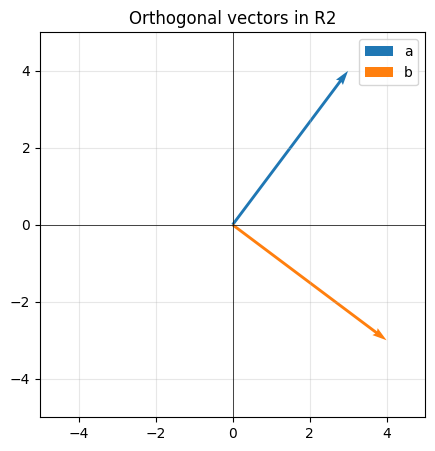

In [19]:
a = np.array([3, 4], dtype=float)
b = np.array([4, -3], dtype=float)

dot_ab = np.dot(a, b)
angle = np.degrees(np.arccos(dot_ab / (np.linalg.norm(a) * np.linalg.norm(b))))
projection_of_a_on_b = (np.dot(a, b) / np.dot(b, b)) * b

print("a dot b =", dot_ab)
print("angle in degrees =", angle)
print("projection of a onto b =", projection_of_a_on_b)

plt.figure(figsize=(5, 5))
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", label="a")
plt.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1, color="tab:orange", label="b")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.gca().set_aspect("equal", adjustable="box")
plt.legend()
plt.title("Orthogonal vectors in R2")
plt.show()

The zero vector is orthogonal to every vector in the linear space, including itself.

In [20]:
#NEW
a = np.array([3, 4], dtype=float)
z = np.array([0, 0], dtype=float)

dot_az = np.dot(a, z)

print("a dot 0 =", dot_az)

a dot 0 = 0.0


Any set of non-zero mutually orthogonal vectors is linearly independent.

## 1.2.3 Gram-Schmidt Process

The Gram-Schmidt process converts a linearly independent set of vectors into an orthonormal basis for the same span. The loop below subtracts projections onto earlier basis vectors, then normalizes the remaining component.

In [21]:
def gram_schmidt(columns):
    basis = []
    for x in columns.T:
        y = x.astype(float).copy()
        for q in basis:
            y -= np.dot(q, y) * q
        norm_y = np.linalg.norm(y)
        if norm_y < 1e-12:
            raise ValueError("Input vectors are linearly dependent or nearly dependent.")
        basis.append(y / norm_y)
    return np.column_stack(basis)

A = np.array([
    [1, 1, 0],
    [1, 0, 1],
    [0, 1, 1],
], dtype=float)

Q = gram_schmidt(A)
print("Original column vectors A:")
print(A)
print("\nOrthonormal basis Q:")
print(Q)
print("\nQ.T @ Q should be the identity matrix:")
print(Q.T @ Q)
print("All close to identity?", np.allclose(Q.T @ Q, np.eye(3)))

print()
#NEW
q0=Q[0]
q1=Q[1]
q2=Q[2]
print("||q0||", np.linalg.norm(q0))
print("||q1||", np.linalg.norm(q1))
print("||q2||", np.linalg.norm(q2))
print("q0*q1", np.dot(q0,q1))
print("q0*q2", np.dot(q0,q2))
print("q1*q2", np.dot(q1,q2))
print("Dot products are 0, give or take floating point artifacts.")

Original column vectors A:
[[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]]

Orthonormal basis Q:
[[ 0.7071  0.4082 -0.5774]
 [ 0.7071 -0.4082  0.5774]
 [ 0.      0.8165  0.5774]]

Q.T @ Q should be the identity matrix:
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
All close to identity? True

||q0|| 1.0
||q1|| 1.0
||q2|| 1.0
q0*q1 -1.6653345369377348e-16
q0*q2 2.7755575615628914e-16
q1*q2 0.0
Dot products are 0, give or take floating point artifacts.


## 1.2.4 Eigenvalues and Eigenvectors

For a square matrix A, an eigenvector v keeps its direction when multiplied by A. Only its scale changes: `A v = lambda v`, where lambda is the eigenvalue.

In [22]:
M = np.array([
    [2, 1],
    [1, 2],
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(M)
print("Matrix M:")
print(M)
print("eigenvalues =", eigenvalues)
print("eigenvectors as columns:")
print(eigenvectors)

for i, lam in enumerate(eigenvalues):
    vec = eigenvectors[:, i]
    residual = M @ vec - lam * vec
    print(f"\nEigenpair {i+1}")
    print("lambda =", lam)
    print("v =", vec)
    print("M @ v =", M @ vec)
    print("lambda * v =", lam * vec)
    print("residual norm =", np.linalg.norm(residual))

Matrix M:
[[2. 1.]
 [1. 2.]]
eigenvalues = [3. 1.]
eigenvectors as columns:
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Eigenpair 1
lambda = 3.0
v = [0.7071 0.7071]
M @ v = [2.1213 2.1213]
lambda * v = [2.1213 2.1213]
residual norm = 0.0

Eigenpair 2
lambda = 1.0
v = [-0.7071  0.7071]
M @ v = [-0.7071  0.7071]
lambda * v = [-0.7071  0.7071]
residual norm = 0.0


NEW

A v = lambda v can be rearranged like so:

A * v = lambda * v

A * v - lambda * v = 0

(A - lambda * I) * v = 0

Where I is the identity matrix. Multiplying by I is used to make the subtraction be a matrix minus another matrix.

Since v is nonzero, it must live in the null space of (A - lambda * I), so (A - lambda * I) must be linearly dependent and has determinant 0.



## Reflection and Submission Checklist

- I explained each concept in words before or after the code.
- I verified important claims numerically, such as dot products, norms, identities, or residuals.
- I changed or extended at least one example so the notebook reflects my own work.
- I ran the notebook from top to bottom without errors.
- I saved the notebook from Google Colab directly to GitHub, following the course instructions.